# 4.2 Evaluate test predictions for 2025-2026

Run after `4_1_generate_test_predictions.ipynb`. Evaluates only forecasts issued from 1 January 2025 through 31 December 2026 (end exclusive: 1 January 2027). All horizons of each selected forecast origin are retained. Displays pooled and per-horizon metrics for the central stacker and benchmarks (value-signal evaluation is commented out), plus a single-column, portrait MAE plot.

The available origin range and row counts by year are printed below. If the archive contains no 2026 origins, the results cover only the available 2025 origins.

AEMO predispatch is intentionally evaluated only through horizon 78 (39 hours), matching the archive generator. Later horizons are outside its supported range, not missing forecasts or errors. Availability is measured only within each method's supported range; pooled scores can therefore cover different lead times.


In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [2]:
sys.path.append(os.path.abspath("../../"))
from EPF import variables

In [3]:
EVALUATION_START = pd.Timestamp("2025-01-01")
EVALUATION_END_EXCLUSIVE = pd.Timestamp("2027-01-01")

all_predictions = pd.read_csv(
    variables.ACTUAL_VS_PREDICTED_TEST_SET, parse_dates=["forecast_origin"]
)
all_predictions = all_predictions.loc[
    (all_predictions["forecast_origin"] >= EVALUATION_START)
    & (all_predictions["forecast_origin"] < EVALUATION_END_EXCLUSIVE)
].copy()
if all_predictions.empty:
    raise ValueError("No forecast origins from 2025 or 2026 are available in the prediction archive.")

origins = all_predictions["forecast_origin"]
year_counts = origins.dt.year.value_counts().reindex([2025, 2026], fill_value=0).sort_index()
print(f"Evaluating {len(all_predictions):,} forecast origins: {origins.min()} to {origins.max()}")
print("Forecast origins by year:")
print(year_counts.rename("forecast_origins").to_string())
missing_years = year_counts.index[year_counts == 0].tolist()
if missing_years:
    print("No forecast origins available for: " + ", ".join(map(str, missing_years)))

evaluation_period_label = f"origins {origins.min():%Y-%m-%d} to {origins.max():%Y-%m-%d}"
display(all_predictions.head(10))


Evaluating 17,520 forecast origins: 2025-01-01 00:00:00 to 2025-12-31 23:30:00
Forecast origins by year:
forecast_origin
2025    17520
2026        0
No forecast origins available for: 2026


,forecast_origin,actual_h1,actual_h2,actual_h3,actual_h4,actual_h5,actual_h6,actual_h7,actual_h8,actual_h9,actual_h10,actual_h11,actual_h12,actual_h13,actual_h14,actual_h15,actual_h16,actual_h17,actual_h18,actual_h19,actual_h20,actual_h21,actual_h22,actual_h23,actual_h24,actual_h25,actual_h26,actual_h27,actual_h28,actual_h29,actual_h30,actual_h31,actual_h32,actual_h33,actual_h34,actual_h35,actual_h36,actual_h37,actual_h38,actual_h39,actual_h40,actual_h41,actual_h42,actual_h43,actual_h44,actual_h45,actual_h46,actual_h47,actual_h48,actual_h49,actual_h50,actual_h51,actual_h52,actual_h53,actual_h54,actual_h55,actual_h56,actual_h57,actual_h58,actual_h59,actual_h60,actual_h61,actual_h62,actual_h63,actual_h64,actual_h65,actual_h66,actual_h67,actual_h68,actual_h69,actual_h70,actual_h71,actual_h72,actual_h73,actual_h74,actual_h75,actual_h76,actual_h77,actual_h78,actual_h79,actual_h80,actual_h81,actual_h82,actual_h83,actual_h84,actual_h85,actual_h86,actual_h87,actual_h88,actual_h89,actual_h90,actual_h91,actual_h92,actual_h93,actual_h94,actual_h95,actual_h96,predicted_h1,predicted_h2,predicted_h3,predicted_h4,predicted_h5,predicted_h6,predicted_h7,predicted_h8,predicted_h9,predicted_h10,predicted_h11,predicted_h12,predicted_h13,predicted_h14,predicted_h15,predicted_h16,predicted_h17,predicted_h18,predicted_h19,predicted_h20,predicted_h21,predicted_h22,predicted_h23,predicted_h24,predicted_h25,predicted_h26,predicted_h27,predicted_h28,predicted_h29,predicted_h30,predicted_h31,predicted_h32,predicted_h33,predicted_h34,predicted_h35,predicted_h36,predicted_h37,predicted_h38,predicted_h39,predicted_h40,predicted_h41,predicted_h42,predicted_h43,predicted_h44,predicted_h45,predicted_h46,predicted_h47,predicted_h48,predicted_h49,predicted_h50,predicted_h51,predicted_h52,predicted_h53,predicted_h54,predicted_h55,predicted_h56,predicted_h57,predicted_h58,predicted_h59,predicted_h60,predicted_h61,predicted_h62,predicted_h63,predicted_h64,predicted_h65,predicted_h66,predicted_h67,predicted_h68,predicted_h69,predicted_h70,predicted_h71,predicted_h72,predicted_h73,predicted_h74,predicted_h75,predicted_h76,predicted_h77,predicted_h78,predicted_h79,predicted_h80,predicted_h81,predicted_h82,predicted_h83,predicted_h84,predicted_h85,predicted_h86,predicted_h87,predicted_h88,predicted_h89,predicted_h90,predicted_h91,predicted_h92,predicted_h93,predicted_h94,predicted_h95,predicted_h96,naive_h1,naive_h2,naive_h3,naive_h4,naive_h5,naive_h6,naive_h7,naive_h8,naive_h9,naive_h10,naive_h11,naive_h12,naive_h13,naive_h14,naive_h15,naive_h16,naive_h17,naive_h18,naive_h19,naive_h20,naive_h21,naive_h22,naive_h23,naive_h24,naive_h25,naive_h26,naive_h27,naive_h28,naive_h29,naive_h30,naive_h31,naive_h32,naive_h33,naive_h34,naive_h35,naive_h36,naive_h37,naive_h38,naive_h39,naive_h40,naive_h41,naive_h42,naive_h43,naive_h44,naive_h45,naive_h46,naive_h47,naive_h48,naive_h49,naive_h50,naive_h51,naive_h52,naive_h53,naive_h54,naive_h55,naive_h56,naive_h57,naive_h58,naive_h59,naive_h60,naive_h61,naive_h62,naive_h63,naive_h64,naive_h65,naive_h66,naive_h67,naive_h68,naive_h69,naive_h70,naive_h71,naive_h72,naive_h73,naive_h74,naive_h75,naive_h76,naive_h77,naive_h78,naive_h79,naive_h80,naive_h81,naive_h82,naive_h83,naive_h84,naive_h85,naive_h86,naive_h87,naive_h88,naive_h89,naive_h90,naive_h91,naive_h92,naive_h93,naive_h94,naive_h95,naive_h96,operating_protocol_h1,operating_protocol_h2,operating_protocol_h3,operating_protocol_h4,operating_protocol_h5,operating_protocol_h6,operating_protocol_h7,operating_protocol_h8,operating_protocol_h9,operating_protocol_h10,operating_protocol_h11,operating_protocol_h12,operating_protocol_h13,operating_protocol_h14,operating_protocol_h15,operating_protocol_h16,operating_protocol_h17,operating_protocol_h18,operating_protocol_h19,operating_protocol_h20,operating_protocol_h21,operating_protocol_h22,operating_protocol_h23,operating_protocol_h24,operating_protocol_h25,operating_protocol_h26,operating_protocol_h27,operating_protocol_h28,operating_proto

In [4]:
HORIZON_LIST = range(1, variables.HORIZON_COUNT + 1)
# Match AEMO_MAX_HORIZON in 4_1_generate_test_predictions.ipynb.
AEMO_MAX_HORIZON = min(78, variables.HORIZON_COUNT)
AEMO_MAX_LEAD_HOURS = AEMO_MAX_HORIZON * variables.HORIZON_GRANULARITY_IN_MINUTES / 60
print(f"AEMO is evaluated only through {AEMO_MAX_LEAD_HOURS:g} hours; later horizons are outside its supported range.")

predictions = {
    name: all_predictions[[f"{name}_h{horizon}" for horizon in HORIZON_LIST]].to_numpy(dtype=np.float32)
    for name in (
        "actual",
        "predicted",
        # "value_signal",
        "naive",
        "operating_protocol",
        "aemo_predispatch",
    )
}

AEMO is evaluated only through 39 hours; later horizons are outside its supported range.


In [5]:
# Score every method by horizon and across the selected 2025-2026 origins

cases = []
for column, horizon in enumerate(HORIZON_LIST):
    actual = predictions["actual"][:, column]
    for method, name in (
        ("predicted", "residual_stacker"),
        # ("value_signal", "value_signal"),
        ("naive", "naive_48h_block_persistence"),
        ("operating_protocol", "operating_protocol"),
        ("aemo_predispatch", "aemo_predispatch"),
    ):
        if method == "aemo_predispatch" and horizon > AEMO_MAX_HORIZON:
            continue  # Outside AEMO's supported range: no score or availability penalty.
        predicted = predictions[method][:, column]
        cases.append((horizon, name, actual, predicted))

for method, name in (
    ("predicted", "residual_stacker"),
    # ("value_signal", "value_signal"),
    ("naive", "naive_48h_block_persistence"),
    ("operating_protocol", "operating_protocol"),
    ("aemo_predispatch", "aemo_predispatch"),
):
    last_horizon = AEMO_MAX_HORIZON if method == "aemo_predispatch" else variables.HORIZON_COUNT
    cases.append((None, name,
                  predictions["actual"][:, :last_horizon].ravel(),
                  predictions[method][:, :last_horizon].ravel()))

metric_names = (
    "mae", "rmse", "r2", "mbe", "wmape", "spike_mae", "dip_mae", "normal_mae",
    "spike_precision", "spike_recall", "spike_f2", "dip_precision", "dip_recall",
)
metrics_by_case = {}
for horizon, method, actual, predicted in cases:
    valid = np.isfinite(actual) & np.isfinite(predicted)
    count = int(valid.sum())
    if not count:
        metrics = {"n": 0, "n_expected_within_range": len(valid), "availability_within_range_pct": 0.0, **dict.fromkeys(metric_names, np.nan)}
    else:
        actual = actual[valid].astype(float)
        predicted = predicted[valid].astype(float)
        error = predicted - actual
        absolute_error = np.abs(error)
        spikes = actual > variables.SPIKE_THRESHOLD
        dips = actual < variables.DIP_THRESHOLD
        normal = ~(spikes | dips)
        predicted_spikes = predicted > variables.SPIKE_THRESHOLD
        predicted_dips = predicted < variables.DIP_THRESHOLD

        spike_true_positives = np.count_nonzero(spikes & predicted_spikes)
        spike_predicted_positives = predicted_spikes.sum()
        spike_actual_positives = spikes.sum()
        spike_precision = spike_true_positives / spike_predicted_positives if spike_predicted_positives else np.nan
        spike_recall = spike_true_positives / spike_actual_positives if spike_actual_positives else np.nan
        spike_f2 = 5 * spike_precision * spike_recall / (4 * spike_precision + spike_recall) if np.isfinite(spike_precision + spike_recall) and spike_precision + spike_recall else np.nan

        dip_true_positives = np.count_nonzero(dips & predicted_dips)
        dip_predicted_positives = predicted_dips.sum()
        dip_actual_positives = dips.sum()
        dip_precision = dip_true_positives / dip_predicted_positives if dip_predicted_positives else np.nan
        dip_recall = dip_true_positives / dip_actual_positives if dip_actual_positives else np.nan

        metrics = {
            "n": count,
            "n_expected_within_range": len(valid),
            "availability_within_range_pct": 100 * count / len(valid),
            "mae": float(absolute_error.mean()),
            "rmse": float(np.sqrt(np.mean(error**2))),
            "r2": float(r2_score(actual, predicted)) if count >= 2 else np.nan,
            "mbe": float(error.mean()),
            "wmape": float(100 * absolute_error.sum() / (np.abs(actual).sum() + 1e-8)),
            "spike_mae": float(absolute_error[spikes].mean()) if spikes.any() else np.nan,
            "dip_mae": float(absolute_error[dips].mean()) if dips.any() else np.nan,
            "normal_mae": float(absolute_error[normal].mean()) if normal.any() else np.nan,
            "spike_precision": float(spike_precision),
            "spike_recall": float(spike_recall),
            "spike_f2": float(spike_f2),
            "dip_precision": float(dip_precision),
            "dip_recall": float(dip_recall),
        }
    metrics_by_case[(horizon, method)] = metrics

In [6]:
# Assemble the same per-horizon benchmark tables

benchmark_metrics = pd.DataFrame([
    {"horizon": horizon, "lead_hours": horizon * variables.HORIZON_GRANULARITY_IN_MINUTES / 60,
     "method": method, **metrics_by_case[(horizon, method)]}
    for horizon in HORIZON_LIST
    for method in (
        "residual_stacker",
        # "value_signal",
        "naive_48h_block_persistence",
        "operating_protocol",
        "aemo_predispatch",
    )
    if (horizon, method) in metrics_by_case
])

benchmark_by_horizon = []
for horizon in HORIZON_LIST:
    central = metrics_by_case[(horizon, "residual_stacker")]
    naive = metrics_by_case[(horizon, "naive_48h_block_persistence")]
    protocol = metrics_by_case[(horizon, "operating_protocol")]
    aemo_in_range = horizon <= AEMO_MAX_HORIZON
    aemo = metrics_by_case.get(
        (horizon, "aemo_predispatch"),
        {**dict.fromkeys(metric_names, np.nan), "availability_within_range_pct": np.nan},
    )
    column = horizon - 1
    actual_prices = predictions["actual"][:, column]
    model_prices = predictions["predicted"][:, column]
    naive_prices = predictions["naive"][:, column]
    aemo_prices = predictions["aemo_predispatch"][:, column]
    common = aemo_in_range & np.isfinite(actual_prices) & np.isfinite(aemo_prices)
    model_common = common & np.isfinite(model_prices)
    naive_common = common & np.isfinite(naive_prices)
    model_common_mae = float(np.abs(model_prices[model_common].astype(float) - actual_prices[model_common].astype(float)).mean()) if model_common.any() else np.nan
    naive_common_mae = float(np.abs(naive_prices[naive_common].astype(float) - actual_prices[naive_common].astype(float)).mean()) if naive_common.any() else np.nan
    aemo_common_mae = float(np.abs(aemo_prices[common].astype(float) - actual_prices[common].astype(float)).mean()) if common.any() else np.nan
    benchmark_by_horizon.append({
        "horizon": horizon,
        "lead_hours": horizon * variables.HORIZON_GRANULARITY_IN_MINUTES / 60,
        "model_mae": central["mae"],
        "naive_mae": naive["mae"],
        "operating_protocol_mae": protocol["mae"],
        "aemo_mae": aemo["mae"],
        "model_rmse": central["rmse"],
        "naive_rmse": naive["rmse"],
        "operating_protocol_rmse": protocol["rmse"],
        "aemo_rmse": aemo["rmse"],
        "aemo_coverage": "Within supported range" if aemo_in_range else "Outside supported range",
        "aemo_availability_within_range_pct": aemo["availability_within_range_pct"],
        "model_mae_skill_vs_naive_pct": 100 * (naive["mae"] - central["mae"]) / naive["mae"] if np.isfinite(naive["mae"]) and naive["mae"] else np.nan,
        "model_rmse_skill_vs_naive_pct": 100 * (naive["rmse"] - central["rmse"]) / naive["rmse"] if np.isfinite(naive["rmse"]) and naive["rmse"] else np.nan,
        "central_spike_mae": central["spike_mae"],
        "central_spike_precision": central["spike_precision"],
        "central_spike_recall": central["spike_recall"],
        "central_spike_f2": central["spike_f2"],
        "model_mae_on_aemo_sample": model_common_mae,
        "naive_mae_on_aemo_sample": naive_common_mae,
        "model_mae_skill_vs_aemo_pct": 100 * (aemo_common_mae - model_common_mae) / aemo_common_mae if np.isfinite(aemo_common_mae) and aemo_common_mae else np.nan,
    })
benchmark_by_horizon = pd.DataFrame(benchmark_by_horizon)

Pooled scores use each method's supported lead range. Availability excludes unsupported horizons.
AEMO values beyond its supported range are N/A, not forecast errors. Pooled lead ranges differ by method.


,method,max_lead_hours,n,n_expected_within_range,availability_within_range_pct,mae,rmse,r2,mbe,wmape,spike_mae,dip_mae,normal_mae,spike_precision,spike_recall,spike_f2,dip_precision,dip_recall
0,residual_stacker,48.0,1681920,1681920,100.0000,46.9519,373.8448,0.0554,-17.9622,43.5989,185.2030,33.3778,21.7342,0.7108,0.5512,0.5771,0.7966,0.3701
1,naive_48h_block_persistence,48.0,1681920,1681920,100.0000,81.3139,527.8015,-0.8828,0.1862,75.5070,300.6269,46.0192,43.7892,0.4391,0.4394,0.4393,0.5310,0.5303
2,operating_protocol,48.0,1681920,1681920,100.0000,74.0533,385.5800,-0.0048,-0.0161,68.7649,255.3501,46.9044,42.6680,0.4784,0.4128,0.4245,0.4971,0.1948
3,aemo_predispatch,39.0,1287967,1366560,94.2488,139.5760,1210.9852,-8.3562,85.4936,128.9145,625.5954,49.4873,59.9141,0.6317,0.5420,0.5578,0.6946,0.4617


,horizon,lead_hours,model_mae,naive_mae,operating_protocol_mae,aemo_mae,model_rmse,naive_rmse,operating_protocol_rmse,aemo_rmse,aemo_coverage,aemo_availability_within_range_pct,model_mae_skill_vs_naive_pct,model_rmse_skill_vs_naive_pct,central_spike_mae,central_spike_precision,central_spike_recall,central_spike_f2,model_mae_on_aemo_sample,naive_mae_on_aemo_sample,model_mae_skill_vs_aemo_pct
0,1,0.5,30.8442,81.3681,73.9276,50.4045,361.7678,527.8067,385.5066,573.6373,Within supported range,94.5148,62.093,31.4583,149.5017,0.8888,0.8182,0.8314,31.4691,83.5597,37.567
1,2,1.0,35.6409,81.366,73.9253,60.5056,369.7919,527.8066,385.5066,672.2839,Within supported range,94.5148,56.1968,29.938,162.8799,0.8364,0.7407,0.758,35.9987,83.5639,40.5035
2,3,1.5,38.2213,81.3638,73.9243,69.3502,370.8469,527.8065,385.5069,749.0281,Within supported range,94.5148,53.0242,29.7381,167.7965,0.8128,0.6974,0.7178,38.0835,83.5701,45.0851
3,4,2.0,39.8882,81.3622,73.9266,83.1193,371.1842,527.8065,385.5074,879.6142,Within supported range,94.5148,50.9745,29.6742,170.6028,0.8015,0.6946,0.7137,39.4827,83.5734,52.4987
4,5,2.5,40.5915,81.3613,73.927,91.7599,371.5799,527.8064,385.5076,949.9776,Within supported range,94.5148,50.1095,29.5992,172.7868,0.7942,0.656,0.6797,40.4638,83.5713,55.9025
5,6,3.0,41.8505,81.361,73.9283,93.4763,371.6796,527.8064,385.5079,956.0926,Within supported range,94.5148,48.562,29.5803,173.5242,0.7713,0.649,0.6702,41.5503,83.5638,55.5499
6,7,3.5,40.6967,81.3606,73.9294,96.1141,371.1741,527.8064,385.5081,973.6374,Within supported range,94.5148,49.9798,29.6761,175.6295,0.7971,0.6061,0.6366,40.6211,83.5567,57.7365
7,8,4.0,41.6813,81.3603,73.9319,104.3963,371.3771,527.8064,385.5083,1030.6195,Within supported range,94.5148,48.7695,29.6376,177.7391,0.8025,0.5789,0.6131,41.7077,83.5486,60.0487
8,9,4.5,41.4379,81.3604,73.935,114.5331,371.8661,527.8064,385.5085,1104.841,Within supported range,94.5148,49.0687,29.545,177.7183,0.7852,0.5884,0.6194,41.4233,83.541,63.8329
9,10,5.0,42.3914,81.3602,73.9364,128.9044,372.1581,527.8064,385.5086,1213.9371,Within supported range,94.5148,47.8967,29.4897,178.2999,0.7596,0.5769,0.6061,42.439,83.5287,67.0771


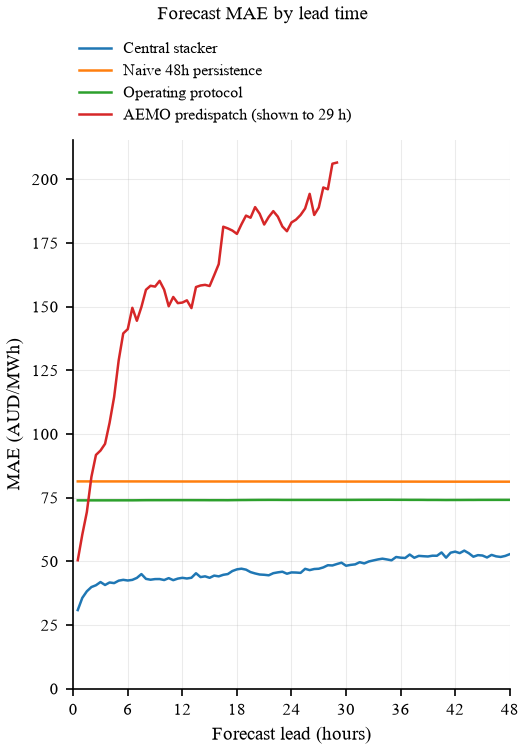

In [7]:
# Pooled metrics and publication MAE plot

pooled_metrics = pd.DataFrame([
    {"method": method,
     "max_lead_hours": (AEMO_MAX_HORIZON if method == "aemo_predispatch" else variables.HORIZON_COUNT)
                       * variables.HORIZON_GRANULARITY_IN_MINUTES / 60,
     **metrics_by_case[(None, method)]}
    for method in (
        "residual_stacker",
        # "value_signal",
        "naive_48h_block_persistence",
        "operating_protocol",
        "aemo_predispatch",
    )
])

print("Pooled scores use each method's supported lead range. Availability excludes unsupported horizons.")
print("AEMO values beyond its supported range are N/A, not forecast errors. Pooled lead ranges differ by method.")
display(pooled_metrics.round(4))
# Format only a display copy; keep numeric metrics unchanged for calculations.
benchmark_display = benchmark_by_horizon.round(4).astype(object)
display(benchmark_display.where(benchmark_display.notna(), "N/A"))

# Display cutoff only; AEMO scoring still uses its full supported range.
AEMO_PLOT_MAX_LEAD_HOURS = 29

# Portrait figure sized for one column of a two-column research paper.
with plt.rc_context({
    "font.family": "Times New Roman",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "svg.fonttype": "none",
}):
    fig, ax = plt.subplots(figsize=(3.5, 5.0), dpi=150, layout="constrained")
    labels = {
        "residual_stacker": "Central stacker",
        # "value_signal": "Decision-focused value signal",
        "naive_48h_block_persistence": "Naive 48h persistence",
        "operating_protocol": "Operating protocol",
        "aemo_predispatch": f"AEMO predispatch (shown to {AEMO_PLOT_MAX_LEAD_HOURS:g} h)",
    }
    for method, label in labels.items():
        rows = benchmark_metrics[benchmark_metrics["method"] == method]
        if method == "aemo_predispatch":
            rows = rows[rows["lead_hours"] <= AEMO_PLOT_MAX_LEAD_HOURS]
        ax.plot(rows["lead_hours"], rows["mae"], label=label, linewidth=1.2)
    ax.set(
        xlabel="Forecast lead (hours)",
        ylabel="MAE (AUD/MWh)",
        xlim=(0, variables.HORIZON_COUNT * variables.HORIZON_GRANULARITY_IN_MINUTES / 60),
        ylim=(0, None),
    )
    ax.set_xticks(np.arange(0, variables.HORIZON_COUNT * variables.HORIZON_GRANULARITY_IN_MINUTES / 60 + 1, 6))
    ax.grid(alpha=0.25, linewidth=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), borderaxespad=0, frameon=False)
    fig.suptitle("Forecast MAE by lead time", fontsize=9)

    figure_dir = variables.MODEL_RESULTS_DIR / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    figure_stem = f"forecast_mae_{origins.min():%Y%m%d}_{origins.max():%Y%m%d}"
    fig.savefig(figure_dir / f"{figure_stem}.png", dpi=600)
    fig.savefig(figure_dir / f"{figure_stem}.svg")
    plt.show()
